## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, LeakyReLU, BatchNormalization, Reshape, Input
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix, recall_score
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
import os
import matplotlib.pyplot as plt
import random
from tensorflow.keras.preprocessing import image

## Exploratory Data Analysis

Number of OSCC images: 2511
Number of Normal images: 2435


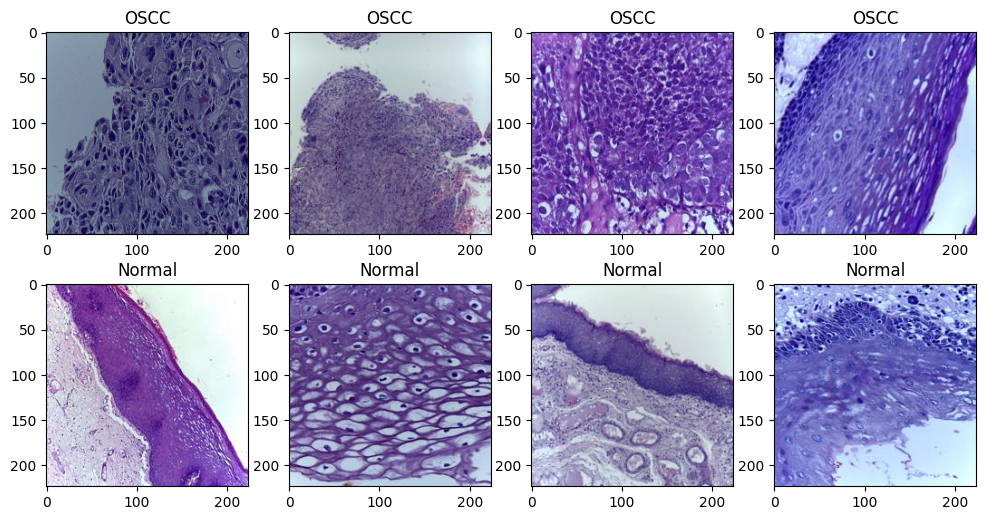

In [5]:
# Dataset
train_data_dir = '/Users/umarranginwala/Desktop/archive_2/train'
oscc_dir = os.path.join(train_data_dir, 'OSCC')
normal_dir = os.path.join(train_data_dir, 'Normal')

# Count the number of images in each class
num_oscc_samples = len(os.listdir(oscc_dir))
num_normal_samples = len(os.listdir(normal_dir))

print("Number of OSCC images:", num_oscc_samples)
print("Number of Normal images:", num_normal_samples)

# Display a random sample of images from each class
plt.figure(figsize=(12, 6))

# Display OSCC images
for i in range(4):
    random_oscc_img = random.choice(os.listdir(oscc_dir))
    img_path = os.path.join(oscc_dir, random_oscc_img)
    img = image.load_img(img_path, target_size=(224, 224))
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title("OSCC")

# Display Normal images
for i in range(4):
    random_normal_img = random.choice(os.listdir(normal_dir))
    img_path = os.path.join(normal_dir, random_normal_img)
    img = image.load_img(img_path, target_size=(224, 224))
    plt.subplot(2, 4, i + 5)
    plt.imshow(img)
    plt.title("Normal")

plt.show()


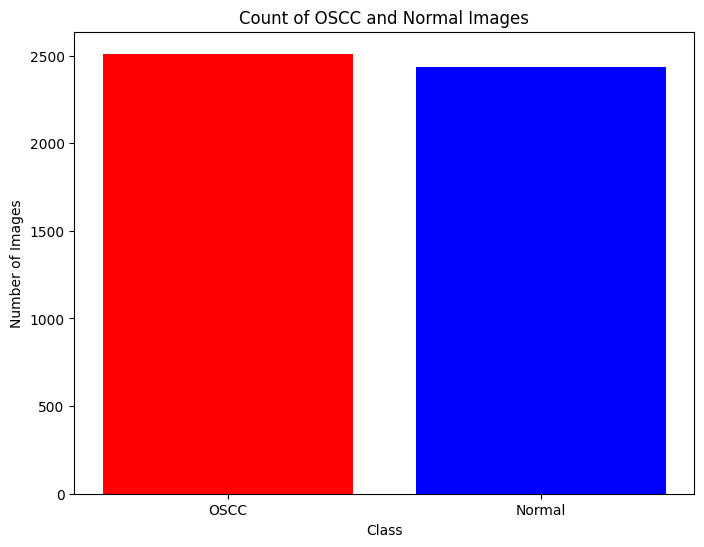

In [6]:
# Dataset
train_data_dir = '/Users/umarranginwala/Desktop/archive_2/train'
oscc_dir = os.path.join(train_data_dir, 'OSCC')
normal_dir = os.path.join(train_data_dir, 'Normal')

# Count the number of images in each class
num_oscc_samples = len(os.listdir(oscc_dir))
num_normal_samples = len(os.listdir(normal_dir))

# Create a bar graph
categories = ['OSCC', 'Normal']
counts = [num_oscc_samples, num_normal_samples]

plt.figure(figsize=(8, 6))
plt.bar(categories, counts, color=['red', 'blue'])
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Count of OSCC and Normal Images')
plt.show()


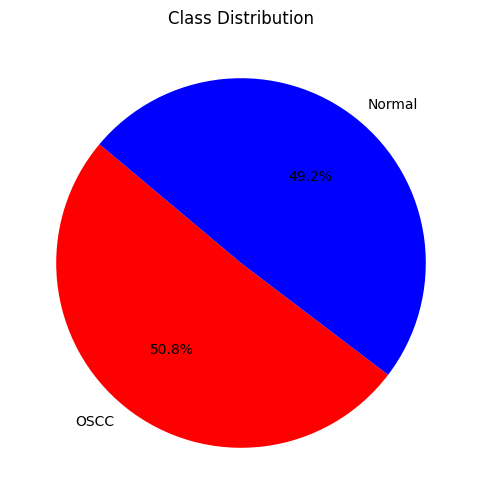

In [7]:
# Define the paths to your dataset
train_data_dir = '/Users/umarranginwala/Desktop/archive_2/train'
oscc_dir = os.path.join(train_data_dir, 'OSCC')
normal_dir = os.path.join(train_data_dir, 'Normal')

# Count the number of images in each class
num_oscc_samples = len(os.listdir(oscc_dir))
num_normal_samples = len(os.listdir(normal_dir))

# Create a pie chart
labels = ['OSCC', 'Normal']
sizes = [num_oscc_samples, num_normal_samples]
colors = ['red', 'blue']

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Class Distribution')
plt.show()


## CNN

### Metrics for CNN
Confusion Matrix:
[[ 0 31]
 [ 0 95]]
Accuracy: 0.753968253968254
F1 Score: 0.8597285067873303
Recall: 1.0

In [3]:
# Define data directories
train_data_dir = '/Users/umarranginwala/Desktop/archive_2/train'
test_data_dir = '/Users/umarranginwala/Desktop/archive_2/test'

# Parameters
input_shape = (224, 224, 3)
batch_size = 32
epochs = 10

# Data Augmentation and Preprocessing
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    shear_range=0.2,
    zoom_range=0.2
)

test_datagen = ImageDataGenerator(rescale=1.0/255.0)

# Data Generators
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=input_shape[:2],
    batch_size=batch_size,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=input_shape[:2],
    batch_size=batch_size,
    class_mode='binary'
)

# Build the CNN model
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs,
    validation_data=test_generator,
    validation_steps=test_generator.samples // batch_size
)

# Evaluate the model on the test set
test_generator.reset()
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred = np.round(y_pred)

# Calculate accuracy and F1 Score
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Accuracy:", accuracy)
print("F1 Score:", f1)

Found 4946 images belonging to 2 classes.
Found 126 images belonging to 2 classes.
Epoch 1/10
154/154 [==============================] - 92s 594ms/step - loss: 0.7140 - accuracy: 0.4949 - val_loss: 0.6925 - val_accuracy: 0.7396
Epoch 2/10
154/154 [==============================] - 92s 592ms/step - loss: 0.6932 - accuracy: 0.5075 - val_loss: 0.6877 - val_accuracy: 0.7812
Epoch 3/10
154/154 [==============================] - 92s 597ms/step - loss: 0.6934 - accuracy: 0.5079 - val_loss: 0.6870 - val_accuracy: 0.7396
Epoch 4/10
154/154 [==============================] - 95s 613ms/step - loss: 0.6932 - accuracy: 0.5075 - val_loss: 0.6878 - val_accuracy: 0.7604
Epoch 5/10
154/154 [==============================] - 92s 596ms/step - loss: 0.6931 - accuracy: 0.5083 - val_loss: 0.6870 - val_accuracy: 0.7500
Epoch 6/10
154/154 [==============================] - 92s 595ms/step - loss: 0.6931 - accuracy: 0.5079 - val_loss: 0.6855 - val_accuracy: 0.7396
Epoch 7/10
154/154 [===========================

In [4]:
# Evaluate the model on the test set
test_generator.reset()
y_pred = model.predict(test_generator)
y_pred = np.round(y_pred).astype(int)
y_true = test_generator.classes

# Calculate accuracy, F1 score, confusion matrix, and recall
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
conf_matrix = confusion_matrix(y_true, y_pred)
recall = recall_score(y_true, y_pred)

# Print the metrics
print("Confusion Matrix:")
print(conf_matrix)
print(f"Accuracy: {accuracy}")
print(f"F1 Score: {f1}")
print(f"Recall: {recall}")

4/4 [==============================] - 6s 1s/step
Confusion Matrix:
[[ 0 31]
 [ 0 95]]
Accuracy: 0.753968253968254
F1 Score: 0.8597285067873303
Recall: 1.0


In [10]:
model.save('orall_cancer_cnn.h5')

/Users/umarranginwala/Library/Python/3.9/lib/python/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


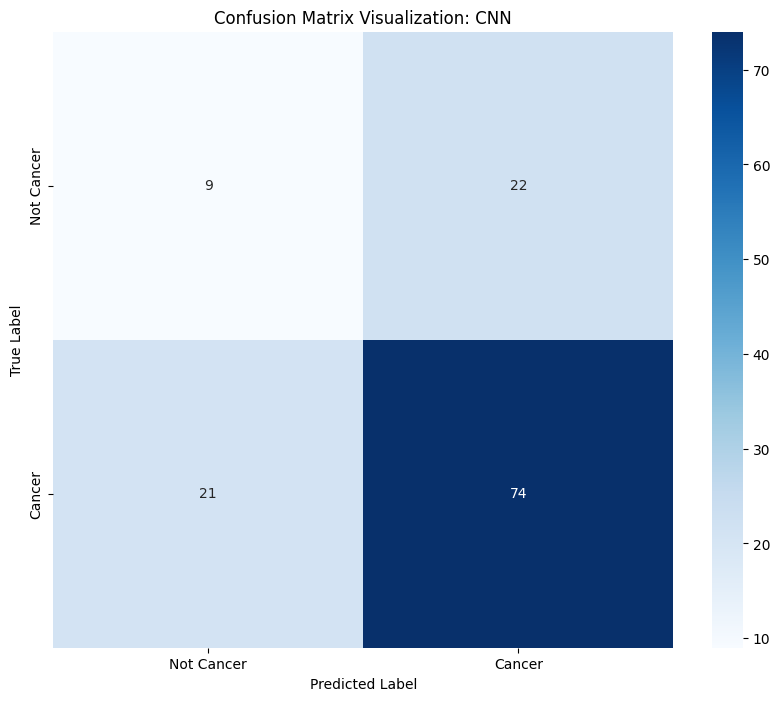

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the confusion matrix
confusion_matrix = np.array([[9, 22],
                             [21, 74]])

# Create labels for the axes with the specified class names
labels = ['Not Cancer', 'Cancer']

# Create a heatmap
plt.figure(figsize=(10, 8))  # You can adjust the figure size as needed
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)

# Add labels and title
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Visualization: CNN')

# Save the figure in high resolution
plt.savefig('confusion_matrix_cnn.png', format='png', dpi=900, bbox_inches='tight')

# Show the plot
plt.show()


In [3]:
import numpy as np
from sklearn.metrics import accuracy_score, recall_score, f1_score

# Define the confusion matrix
confusion_matrix = np.array([[9, 22],
                             [21, 74]])

# Extracting True Positives, False Positives, False Negatives, and True Negatives
TP = confusion_matrix[1, 1]  # True Positives
FP = confusion_matrix[0, 1]  # False Positives
FN = confusion_matrix[1, 0]  # False Negatives
TN = confusion_matrix[0, 0]  # True Negatives

# Calculating metrics
accuracy = (TP + TN) / (TP + FP + FN + TN)
recall = TP / (TP + FN)
precision = TP / (TP + FP)  # Precision is needed for F1 Score calculation
f1 = 2 * (precision * recall) / (precision + recall)

print("Accuracy:", accuracy)
print("Recall:", recall)
print("F1 Score:", f1)


Accuracy: 0.6587301587301587
Recall: 0.7789473684210526
F1 Score: 0.774869109947644


## RESNET 50

In [2]:
# Define data directories
train_data_dir = '/Users/umarranginwala/Desktop/archive_2/train'
test_data_dir = '/Users/umarranginwala/Desktop/archive_2/test'

# Parameters
input_shape = (224, 224, 3)
batch_size = 32
epochs = 10

# Data Augmentation and Preprocessing
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    shear_range=0.2,
    zoom_range=0.2
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Data Generators
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=input_shape[:2],
    batch_size=batch_size,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=input_shape[:2],
    batch_size=batch_size,
    class_mode='binary'
)

# Load Pre-trained ResNet50 Model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)

# Create the full model
model = Model(inputs=base_model.input, outputs=predictions)

# Freeze all layers in the base model
for layer in base_model.layers:
    layer.trainable = False

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs,
    validation_data=test_generator,
    validation_steps=test_generator.samples // batch_size
)

# Evaluate the model on the test set
test_generator.reset()
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred = np.round(y_pred)

# Calculate accuracy and F1 Score
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Accuracy:", accuracy)
print("F1 Score:", f1)

Found 4946 images belonging to 2 classes.
Found 126 images belonging to 2 classes.
4/4 [==============================] - 8s 2s/step
Accuracy: 0.6428571428571429
F1 Score: 0.7715736040609137


In [3]:
from tensorflow.keras.utils import plot_model

In [4]:
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


In [12]:
# Ensure test_generator is reset before prediction
test_generator.reset()

# Predict the output
y_pred = model.predict(test_generator)
y_pred = np.round(y_pred).astype(int)

# True labels
y_true = test_generator.classes

# Calculate accuracy, F1 score, confusion matrix, and recall
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
conf_matrix = confusion_matrix(y_true, y_pred)
recall = recall_score(y_true, y_pred)

# Print the metrics
print("Confusion Matrix:")
print(conf_matrix)
print(f"Accuracy: {accuracy}")
print(f"F1 Score: {f1}")
print(f"Recall: {recall}")

4/4 [==============================] - 8s 2s/step
Confusion Matrix:
[[ 3 28]
 [18 77]]
Accuracy: 0.6349206349206349
F1 Score: 0.77
Recall: 0.8105263157894737


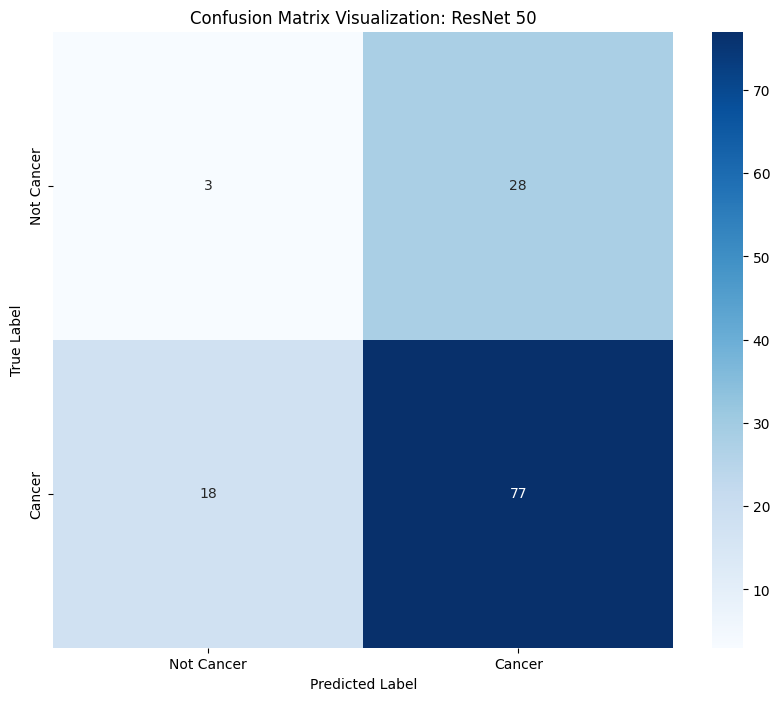

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the confusion matrix
confusion_matrix = np.array([[3,28],
                             [18,77]])

# Create labels for the axes with the specified class names
labels = ['Not Cancer', 'Cancer']

# Create a heatmap
plt.figure(figsize=(10, 8))  # You can adjust the figure size as needed
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)

# Add labels and title
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Visualization: ResNet 50')

# Save the figure in high resolution
plt.savefig('confusion_matrix_cnn50.png', format='png', dpi=900, bbox_inches='tight')

# Show the plot
plt.show()


In [4]:
import numpy as np
from sklearn.metrics import accuracy_score, recall_score, f1_score

# Define the confusion matrix
confusion_matrix = np.array([[3,28],
                             [18,77]])

# Extracting True Positives, False Positives, False Negatives, and True Negatives
TP = confusion_matrix[1, 1]  # True Positives
FP = confusion_matrix[0, 1]  # False Positives
FN = confusion_matrix[1, 0]  # False Negatives
TN = confusion_matrix[0, 0]  # True Negatives

# Calculating metrics
accuracy = (TP + TN) / (TP + FP + FN + TN)
recall = TP / (TP + FN)
precision = TP / (TP + FP)  # Precision is needed for F1 Score calculation
f1 = 2 * (precision * recall) / (precision + recall)

print("Accuracy:", accuracy)
print("Recall:", recall)
print("F1 Score:", f1)


Accuracy: 0.6349206349206349
Recall: 0.8105263157894737
F1 Score: 0.77
